# Vaidya Nidaan — Alzheimer's MRI classifier (v2)

Same architecture as `final_alzheimer_model.ipynb` (VGG-19 + dense head, 128×128 axial slices from OASIS-1), retrained with:

| | v1 | v2 |
|---|---|---|
| Data | `vedjosh/alzheimer-mri` — 38,430 slices (non-demented undersampled to balance) | `ninadaithal/imagesoasis` — all 86,437 slices, class weights instead of discarding data |
| Split | random split over slices | **split by patient** (OAS1_XXXX) — train / val / test share no brains |
| Input scaling | raw 0–255 RGB | VGG-19 ImageNet `preprocess_input` (what the backbone was trained on) |
| Output layer | `Dense(4)` on 2 classes | `Dense(2)` (or 3 for the CDR 0 / 0.5 / ≥1 variant) |
| Training | frozen backbone | head warm-up, then fine-tune `block5` with augmentation |
| Imbalance | undersample to 50/50 | stratified patient split, class-weighted loss, validation-tuned threshold |
| Metrics | slice accuracy | slice **and** patient-level accuracy, balanced accuracy, sensitivity, specificity, ROC-AUC |

**Run on a GPU** (RunPod / Colab / Kaggle). Upload `kaggle.json` first (kaggle.com → Settings → API → Create New Token).
Outputs: `alzheimer_vgg19_v2.keras`, `metrics.json` (config, thresholds, metrics with 95% CIs), `split_subjects.json`, `test_patient_predictions.csv`
→ serve with `MODEL_PREPROCESS=vgg19` and `DECISION_THRESHOLD=<decision_threshold>`.

In [1]:
# !pip install -q "tensorflow[and-cuda]==2.19.0" "keras==3.14.1" -U kagglehub scikit-learn pandas matplotlib seaborn
import os, re, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from PIL import Image
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

for gpu in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(gpu, True)
print("TensorFlow", tf.__version__, "| GPUs:", tf.config.list_physical_devices("GPU"))

SEED = 42
tf.keras.utils.set_random_seed(SEED)
IMG = 128
TASK = "binary"          # "binary" (CDR 0 vs >= 0.5)  or  "3class" (CDR 0 / 0.5 / >= 1)
BATCH = 64
WARMUP_EPOCHS = 4        # head only, frozen backbone
FINETUNE_EPOCHS = 20     # block5 unfrozen (early stopping)
LIMIT = int(os.environ.get("VN_LIMIT", 0))   # >0 = quick smoke test on a subsample
OUT = os.environ.get("VN_OUT", "outputs")
os.makedirs(OUT, exist_ok=True)

2026-09-29 14:55:25.249710: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered


TensorFlow 2.19.0 | GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Data — OASIS-1 axial slices

In [2]:
# Kaggle's new API tokens (KGAT_...) live in ~/.kaggle/access_token; expose it to kagglehub.
tok = os.path.expanduser("~/.kaggle/access_token")
if os.path.exists(tok) and not os.environ.get("KAGGLE_API_TOKEN"):
    os.environ["KAGGLE_API_TOKEN"] = open(tok).read().strip()
import kagglehub

DATA = os.environ.get("VN_DATA") or kagglehub.dataset_download("ninadaithal/imagesoasis")
print("Dataset path:", DATA)

Dataset path: /root/.cache/kagglehub/datasets/ninadaithal/imagesoasis/versions/1


In [3]:
# Folder name -> CDR group. imagesOASIS has 4 severity folders; the vedjosh subset has 2.
FOLDER_CDR = {"non demented": 0.0, "very mild dementia": 0.5, "mild dementia": 1.0,
              "moderate dementia": 2.0, "demented": None}
norm = lambda s: re.sub(r"[\s_\-]+", " ", s.strip().lower())

rows = []
for root, _, files in os.walk(DATA):
    cdr_key = norm(os.path.basename(root))
    if cdr_key not in FOLDER_CDR:
        continue
    for f in files:
        m = re.match(r"(OAS1_\d+)", f)
        if m and f.lower().endswith((".jpg", ".jpeg", ".png")):
            rows.append({"path": os.path.join(root, f), "subject": m.group(1), "folder": cdr_key, "cdr": FOLDER_CDR[cdr_key]})
df = pd.DataFrame(rows).sort_values("path").reset_index(drop=True)
# Some Kaggle mirrors contain the same folder twice; keep one copy of each file name.
n_before = len(df)
df = df.assign(file=df.path.map(os.path.basename)).drop_duplicates("file").drop(columns="file").reset_index(drop=True)
print(f"{len(df)} slices ({n_before - len(df)} duplicate files removed)")

if LIMIT:  # quick smoke test: keep a stratified subset of PATIENTS (all their slices)
    keep = []
    for folder, subs in df.groupby("folder")["subject"].unique().items():
        n = max(6, round(len(subs) * LIMIT / len(df)))
        keep += list(np.random.default_rng(SEED).permutation(sorted(subs))[:n])
    df = df[df.subject.isin(keep)].reset_index(drop=True)

if TASK == "binary":
    CLASSES = ["Non Demented", "Demented"]
    df["label"] = (df["folder"] != "non demented").astype(int)
else:
    # The vedjosh copy merges all severities into one "Demented" folder, so it cannot be split 3 ways.
    assert df["cdr"].notna().all(), "TASK='3class' needs imagesOASIS (separate severity folders), not the merged vedjosh set"
    CLASSES = ["Non Demented (CDR 0)", "Very mild (CDR 0.5)", "Mild+ (CDR >= 1)"]
    df["label"] = df["cdr"].map(lambda c: 0 if c == 0 else (1 if c == 0.5 else 2))
K = len(CLASSES)

# Each patient carries one diagnosis.
assert (df.groupby("subject")["label"].nunique() == 1).all()
counts = df.groupby("label").agg(slices=("path", "size"), patients=("subject", "nunique"))
counts.index = [CLASSES[i] for i in counts.index]
print(counts)
print("\nSlices per original folder:\n", df["folder"].value_counts())

86437 slices (0 duplicate files removed)
              slices  patients
Non Demented   67222       266
Demented       19215        81
Slices per original folder:
 folder
non demented          67222
very mild dementia    13725
mild dementia          5002
moderate dementia       488
Name: count, dtype: int64


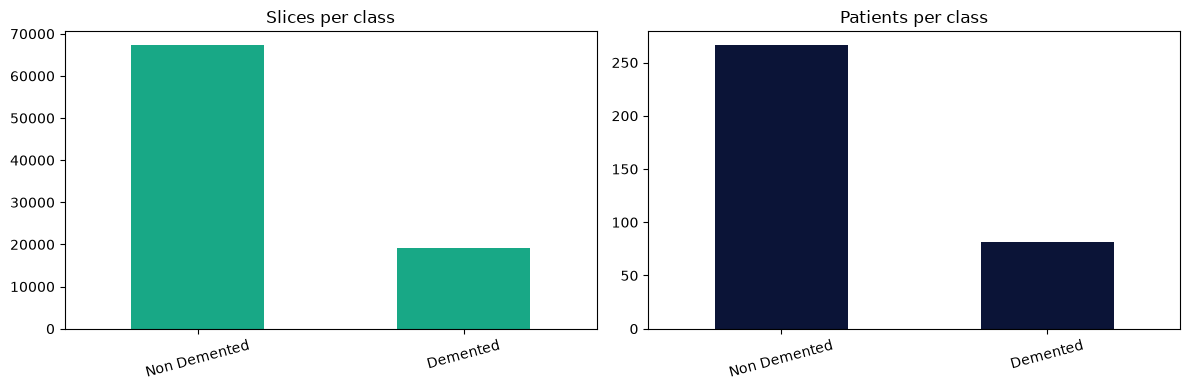

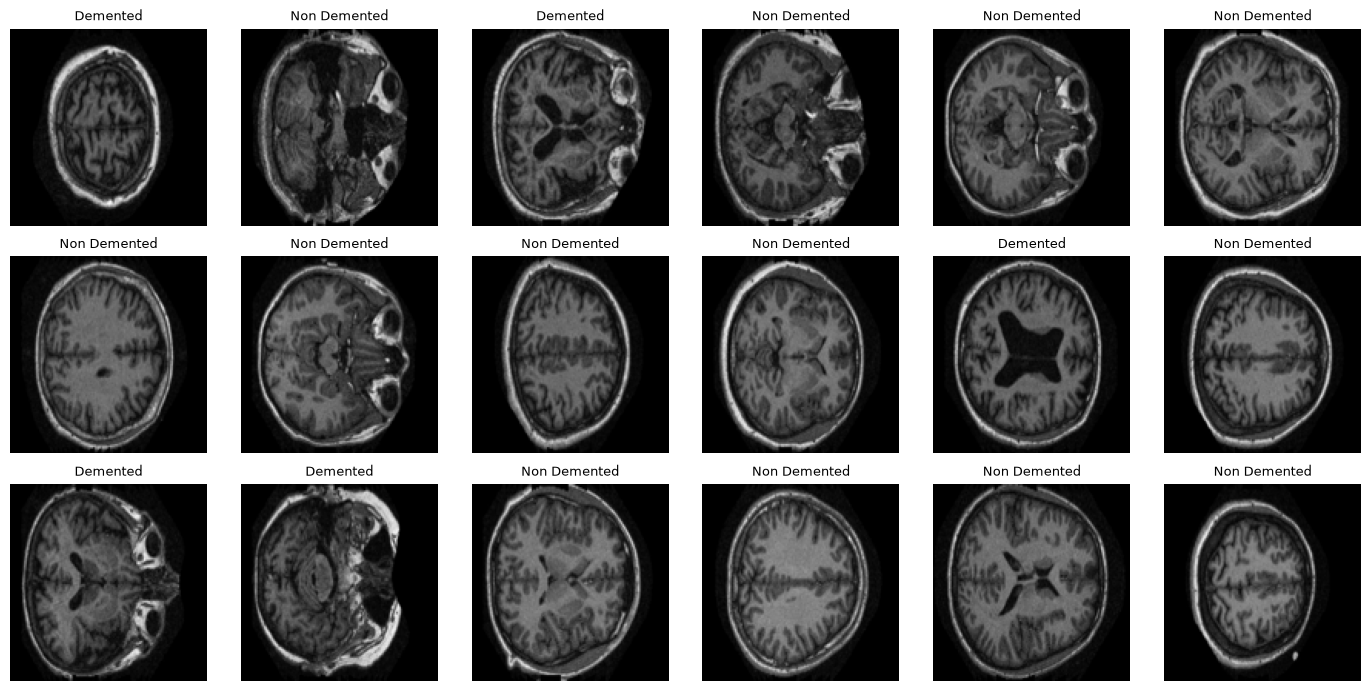

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
counts["slices"].plot.bar(ax=ax[0], color="#18a886", title="Slices per class")
counts["patients"].plot.bar(ax=ax[1], color="#0b1437", title="Patients per class")
for a in ax: a.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

plt.figure(figsize=(14, 7))
for n, i in enumerate(random.Random(SEED).sample(range(len(df)), 18)):
    plt.subplot(3, 6, n + 1)
    plt.imshow(Image.open(df.path[i]).convert("RGB").resize((IMG, IMG)))
    plt.title(CLASSES[df.label[i]], fontsize=9); plt.axis("off")
plt.tight_layout(); plt.show()

## 2. Patient-level split

Every slice of a patient goes to exactly one of train / validation / test (70 / 15 / 15), stratified by diagnosis.
The test set therefore measures performance on **brains the model has never seen**.

In [5]:
rng = np.random.default_rng(SEED)
subj_label = df.groupby("subject")["label"].first()
split = {}
for y in range(K):
    subs = np.array(sorted(subj_label[subj_label == y].index))
    rng.shuffle(subs)
    n_test, n_val = max(1, round(0.15 * len(subs))), max(1, round(0.15 * len(subs)))
    for s in subs[:n_test]: split[s] = "test"
    for s in subs[n_test:n_test + n_val]: split[s] = "val"
    for s in subs[n_test + n_val:]: split[s] = "train"
df["split"] = df["subject"].map(split)

sets = {k: set(df.subject[df.split == k]) for k in ("train", "val", "test")}
assert not (sets["train"] & sets["test"]) and not (sets["train"] & sets["val"]) and not (sets["val"] & sets["test"])
print(df.groupby(["split", "label"]).agg(slices=("path", "size"), patients=("subject", "nunique")))

             slices  patients
split label                  
test  0        9577        40
      1        2867        12
train 0       47458       186
      1       13481        57
val   0       10187        40
      1        2867        12


## 3. Load images, handle class imbalance, build input pipelines

imagesOASIS is imbalanced: ~67k non-demented vs ~19k demented slices (~3.5 : 1), and 266 vs 81 patients.
Instead of discarding 48k non-demented slices (what the v1 dataset did), this notebook:

1. **stratifies the patient split** by diagnosis, so every split keeps the same class ratio;
2. **weights the loss** by inverse class frequency (a demented slice counts ~3.5x a non-demented one);
3. **reports imbalance-aware metrics** — balanced accuracy, sensitivity, specificity, ROC-AUC — not just accuracy;
4. **tunes the decision threshold** on the validation patients (section 6) instead of assuming 0.5.

Images stay as uint8 in memory (~4 GB for the full set) and are streamed to the GPU in batches, so the
dataset never becomes a single >2 GB TensorFlow constant.

In [6]:
def load(paths):
    # Same loading as v1: PIL resize to 128x128, RGB, 0-255 (kept as uint8 to save memory).
    X = np.zeros((len(paths), IMG, IMG, 3), dtype=np.uint8)
    ok = np.ones(len(paths), dtype=bool)
    for i, p in enumerate(paths):
        try:
            X[i] = np.asarray(Image.open(p).convert("RGB").resize((IMG, IMG)))
        except Exception:
            ok[i] = False          # corrupted / unreadable file
    return X, ok

data, subjects = {}, {}
for k in ("train", "val", "test"):
    part = df[df.split == k]
    X, ok = load(part.path.tolist())
    data[k] = (X[ok], part.label.to_numpy()[ok].astype(np.int64))
    subjects[k] = part.subject.to_numpy()[ok]
    print(k, data[k][0].shape, "per class:", np.bincount(data[k][1], minlength=K), f"| unreadable skipped: {(~ok).sum()}")
subjects_test = subjects["test"]

# These OASIS slices are stored with the FRONT of the head on the RIGHT, so the left/right
# hemispheres are the top/bottom of the image. A vertical flip mirrors the hemispheres (a
# plausible variation); a horizontal flip would swap front and back (never seen in a real scan).
augment = tf.keras.Sequential([
    layers.RandomFlip("vertical"),
    layers.RandomRotation(0.04),
    layers.RandomZoom(0.08),
    layers.RandomContrast(0.1),
])

def pipeline(X, y, train):
    # Stream batches from the in-memory uint8 array (reshuffled every epoch for training).
    order_rng = np.random.default_rng(SEED)
    def batches():
        idx = order_rng.permutation(len(y)) if train else np.arange(len(y))
        for i in range(0, len(y), BATCH):
            j = idx[i:i + BATCH]
            yield X[j], y[j]
    ds = tf.data.Dataset.from_generator(batches, output_signature=(
        tf.TensorSpec((None, IMG, IMG, 3), tf.uint8), tf.TensorSpec((None,), tf.int64)))
    ds = ds.map(lambda x, t: (tf.cast(x, tf.float32), t), num_parallel_calls=tf.data.AUTOTUNE)
    if train:
        ds = ds.map(lambda x, t: (augment(x, training=True), t), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.map(lambda x, t: (preprocess_input(x), t)).prefetch(tf.data.AUTOTUNE)

train_ds, val_ds, test_ds = (pipeline(*data[k], train=(k == "train")) for k in ("train", "val", "test"))

# Class weights keep the rarer class from being ignored (instead of throwing data away).
y_train = data["train"][1]
class_weight = {c: len(y_train) / (K * max(1, (y_train == c).sum())) for c in range(K)}
print("class weights:", {CLASSES[c]: round(float(w), 3) for c, w in class_weight.items()})

train (60939, 128, 128, 3) per class: [47458 13481] | unreadable skipped: 0
val (13054, 128, 128, 3) per class: [10187  2867] | unreadable skipped: 0
test (12444, 128, 128, 3) per class: [9577 2867] | unreadable skipped: 0


class weights: {'Non Demented': 0.642, 'Demented': 2.26}


## 4. Model — VGG-19 (ImageNet) + dense head

In [7]:
base = VGG19(weights="imagenet", include_top=False, input_shape=(IMG, IMG, 3))
base.trainable = False
x = layers.Flatten(name="flatten")(base.output)
x = layers.Dense(256, activation="relu", name="dense")(x)
x = layers.Dropout(0.5, name="dropout")(x)
x = layers.Dense(128, activation="relu", name="dense_1")(x)
x = layers.Dropout(0.5, name="dropout_1")(x)
out = layers.Dense(K, activation="softmax", name="dense_2")(x)
model = tf.keras.Model(base.input, out, name="vaidya_nidaan_vgg19_v2")
model.summary(show_trainable=True)

Model: "vaidya_nidaan_vgg19_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 128, 128, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ block1_conv1 (Conv2D)       │ (None, 128, 128, 64)  │      1,792 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ block1_conv2 (Conv2D)       │ (None, 128, 128, 64)  │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ block1_pool (MaxPooling2D)  │ (None, 64, 64, 64)    │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ block2_conv1 (Conv2D)       │ (None, 64, 64, 128)   │     73,856 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ block2_conv2 (Conv2D)       │ (None, 64, 64, 128)   │    147,584 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ block2_pool (MaxPooling2D)  │ (None, 32, 32, 128)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ block3_conv1 (Conv2D)       │ (None, 32, 32, 256)   │    295,168 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ block3_conv2 (Conv2D)       │ (None, 32, 32, 256)   │    590,080 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ block3_conv3 (Conv2D)       │ (None, 32, 32, 256)   │    590,080 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ block3_conv4 (Conv2D)       │ (None, 32, 32, 256)   │    590,080 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ block3_pool (MaxPooling2D)  │ (None, 16, 16, 256)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ block4_conv1 (Conv2D)       │ (None, 16, 16, 512)   │  1,180,160 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ block4_conv2 (Conv2D)       │ (None, 16, 16, 512)   │  2,359,808 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ block4_conv3 (Conv2D)       │ (None, 16, 16, 512)   │  2,359,808 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ block4_conv4 (Conv2D)       │ (None, 16, 16, 512)   │  2,359,808 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ block4_pool (MaxPooling2D)  │ (None, 8, 8, 512)     │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ block5_conv1 (Conv2D)       │ (None, 8, 8, 512)     │  2,359,808 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ block5_conv2 (Conv2D)       │ (None, 8, 8, 512)     │  2,359,808 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ block5_conv3 (Conv2D)       │ (None, 8, 8, 512)     │  2,359,808 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ block5_conv4 (Conv2D)       │ (None, 8, 8, 512)     │  2,359,808 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ block5_pool (MaxPooling2D)  │ (None, 4, 4, 512)     │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ flatten (Flatten)           │ (None, 8192)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 256)           │  2,097,408 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 256)           │          0 │   - 

 Total params: 22,154,946 (84.51 MB)

 Trainable params: 2,130,562 (8.13 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

## 5. Train — head warm-up, then fine-tune block5

In [8]:
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_warmup = model.fit(train_ds, validation_data=val_ds, epochs=WARMUP_EPOCHS, class_weight=class_weight)

base.trainable = True
for layer in base.layers:
    layer.trainable = layer.name.startswith("block5")
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
]
hist_ft = model.fit(train_ds, validation_data=val_ds, epochs=FINETUNE_EPOCHS, class_weight=class_weight, callbacks=callbacks)

Epoch 1/4


953/953 ━━━━━━━━━━━━━━━━━━━━ 92s 77ms/step - accuracy: 0.4360 - loss: 0.8769 - val_accuracy: 0.7917 - val_loss: 0.4194
Epoch 2/4
953/953 ━━━━━━━━━━━━━━━━━━━━ 68s 70ms/step - accuracy: 0.4686 - loss: 0.6043 - val_accuracy: 0.7867 - val_loss: 0.3891
Epoch 3/4
953/953 ━━━━━━━━━━━━━━━━━━━━ 71s 73ms/step - accuracy: 0.4890 - loss: 0.5722 - val_accuracy: 0.8133 - val_loss: 0.3803
Epoch 4/4
953/953 ━━━━━━━━━━━━━━━━━━━━ 70s 72ms/step - accuracy: 0.4943 - loss: 0.5445 - val_accuracy: 0.7805 - val_loss: 0.4500
Epoch 1/20
953/953 ━━━━━━━━━━━━━━━━━━━━ 81s 67ms/step - accuracy: 0.5016 - loss: 0.5240 - val_accuracy: 0.8038 - val_loss: 0.4673 - learning_rate: 1.0000e-05
Epoch 2/20
953/953 ━━━━━━━━━━━━━━━━━━━━ 73s 75ms/step - accuracy: 0.6769 - loss: 0.4377 - val_accuracy: 0.8473 - val_loss: 0.3419 - learning_rate: 1.0000e-05
Epoch 3/20
953/953 ━━━━━━━━━━━━━━━━━━━━ 72s 75ms/step - accuracy: 0.8005 - loss: 0.3428 - val_accuracy: 0.8384 - val_loss: 0.6460 - learning_rate: 1.0000e-05
Epoch 4/20
953/953 ━

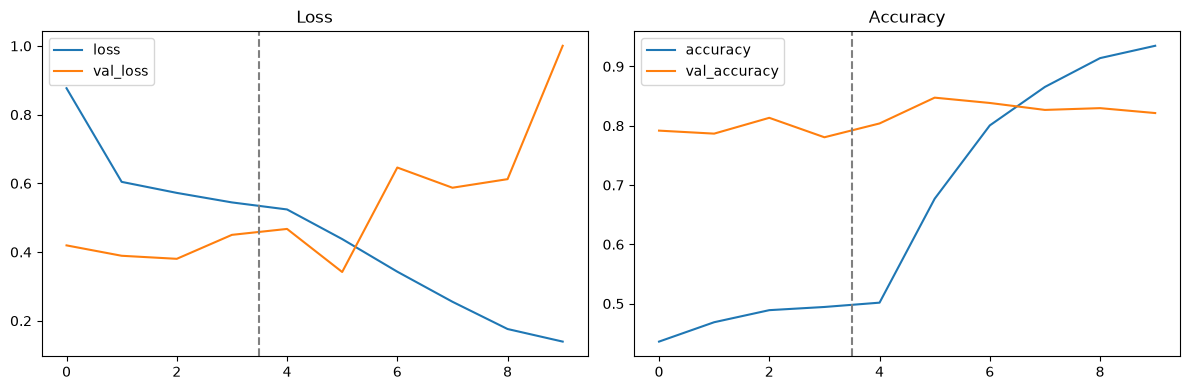

In [9]:
h = {k: hist_warmup.history[k] + hist_ft.history[k] for k in ("loss", "val_loss", "accuracy", "val_accuracy")}
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
pd.DataFrame({"loss": h["loss"], "val_loss": h["val_loss"]}).plot(ax=ax[0], title="Loss")
pd.DataFrame({"accuracy": h["accuracy"], "val_accuracy": h["val_accuracy"]}).plot(ax=ax[1], title="Accuracy")
for a in ax: a.axvline(WARMUP_EPOCHS - 0.5, ls="--", c="grey")
plt.tight_layout(); plt.show()

## 6. Evaluate on held-out patients

Decision thresholds are chosen on the **validation** set (maximising balanced accuracy) and then applied unchanged
to the test set:

- **slice threshold** — for single-slice decisions; this is what the app uses (`DECISION_THRESHOLD`);
- **patient threshold** — for patient-level decisions (average of a patient's slice probabilities).

Patient-level results are the headline numbers, reported with 95% bootstrap confidence intervals over test patients.

In [10]:
X_test, y_test = data["test"]
probs = model.predict(test_ds, verbose=0)
subjects_val = subjects["val"]

def per_patient(p, y, subjects):
    frame = pd.DataFrame(p, columns=range(K)).assign(subject=subjects, y=y).groupby("subject").mean(numeric_only=True)
    return frame[list(range(K))].to_numpy(), frame["y"].astype(int).to_numpy()

def best_threshold(p_dem, y):
    # Threshold on P(Demented) that maximises balanced accuracy (= Youden's J).
    grid = np.linspace(0.05, 0.95, 91)
    bal = [((p_dem >= t)[y == 1].mean() + (p_dem < t)[y == 0].mean()) / 2 for t in grid]
    return float(grid[int(np.argmax(bal))])

SLICE_THRESHOLD = PATIENT_THRESHOLD = 0.5
if K == 2:
    val_probs = model.predict(val_ds, verbose=0)
    SLICE_THRESHOLD = best_threshold(val_probs[:, 1], data["val"][1])
    vp, vy = per_patient(val_probs, data["val"][1], subjects_val)
    PATIENT_THRESHOLD = best_threshold(vp[:, 1], vy)
    print(f"Tuned on validation: slice threshold {SLICE_THRESHOLD:.2f} | patient threshold {PATIENT_THRESHOLD:.2f}")

def decide(p, t):
    return (p[:, 1] >= t).astype(int) if K == 2 else p.argmax(1)

pred = decide(probs, SLICE_THRESHOLD)

def summarize(y, p, pr):
    cm = confusion_matrix(y, pr, labels=list(range(K)))
    recall = cm.diagonal() / cm.sum(1).clip(min=1)
    out = {"n": int(len(y)), "accuracy": float((pr == y).mean()), "balanced_accuracy": float(recall.mean()),
           "recall": {CLASSES[c]: float(recall[c]) for c in range(K)}, "confusion": cm.tolist()}
    if K == 2:
        out.update(sensitivity=float(recall[1]), specificity=float(recall[0]), auc=float(roc_auc_score(y, p[:, 1])))
    else:
        out["macro_auc_ovr"] = float(roc_auc_score(y, p, multi_class="ovr"))
    return out

slice_metrics = summarize(y_test, probs, pred)
print("SLICE LEVEL\n", classification_report(y_test, pred, target_names=CLASSES, digits=3))

# Patient level: average the slice probabilities of each brain -> one decision per patient.
pp, py = per_patient(probs, y_test, subjects_test)
patient_pred = decide(pp, PATIENT_THRESHOLD)
patient_metrics = summarize(py, pp, patient_pred)
print("PATIENT LEVEL\n", classification_report(py, patient_pred, target_names=CLASSES, digits=3))

# 95% confidence intervals: resample the test PATIENTS with replacement 1,000 times.
boot = {k: [] for k in ("balanced_accuracy", "auc", "sensitivity", "specificity")}
rng_b = np.random.default_rng(SEED)
for _ in range(1000):
    i = rng_b.integers(0, len(py), len(py))
    if len(np.unique(py[i])) < K:
        continue
    m = summarize(py[i], pp[i], patient_pred[i])
    for k in boot:
        if k in m: boot[k].append(m[k])
patient_ci = {k: [float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5))] for k, v in boot.items() if v}
for k, (lo, hi) in patient_ci.items():
    print(f"{k:18s} {patient_metrics[k]:.3f}   95% CI [{lo:.3f}, {hi:.3f}]")

Tuned on validation: slice threshold 0.13 | patient threshold 0.32
SLICE LEVEL
               precision    recall  f1-score   support
Non Demented      0.955     0.673     0.789      9577
    Demented      0.450     0.894     0.599      2867
    accuracy                          0.724     12444
   macro avg      0.702     0.783     0.694     12444
weighted avg      0.839     0.724     0.745     12444
PATIENT LEVEL
               precision    recall  f1-score   support
Non Demented      0.935     0.725     0.817        40
    Demented      0.476     0.833     0.606        12
    accuracy                          0.750        52
   macro avg      0.706     0.779     0.711        52
weighted avg      0.829     0.750     0.768        52
balanced_accuracy  0.779   95% CI [0.644, 0.896]
auc                0.890   95% CI [0.790, 0.970]
sensitivity        0.833   95% CI [0.600, 1.000]
specificity        0.725   95% CI [0.581, 0.865]


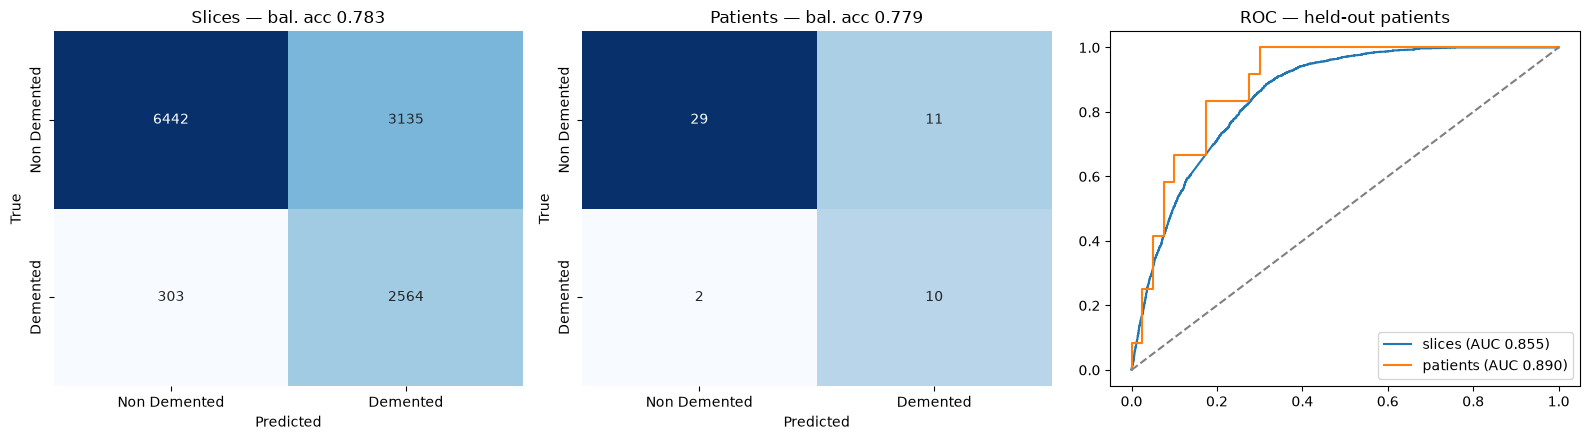

In [11]:
fig, ax = plt.subplots(1, 3 if K == 2 else 2, figsize=(16 if K == 2 else 11, 4.5))
for a, (name, m) in zip(ax, [("Slices", slice_metrics), ("Patients", patient_metrics)]):
    sns.heatmap(np.array(m["confusion"]), annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, ax=a, cbar=False)
    a.set_title(f"{name} — bal. acc {m['balanced_accuracy']:.3f}"); a.set_xlabel("Predicted"); a.set_ylabel("True")
if K == 2:
    for name, y, s in [("slices", y_test, probs[:, 1]), ("patients", py, pp[:, 1])]:
        fpr, tpr, _ = roc_curve(y, s)
        ax[2].plot(fpr, tpr, label=f"{name} (AUC {roc_auc_score(y, s):.3f})")
    ax[2].plot([0, 1], [0, 1], "--", c="grey"); ax[2].set_title("ROC — held-out patients"); ax[2].legend()
plt.tight_layout(); plt.show()

## 7. Grad-CAM++ on held-out patients

Same implementation as the app (`ml_service/inference.py`): gradients of the class log-odds with respect to `block5_conv4`.
Check whether the attribution sits on brain tissue (ventricles, medial temporal lobes) rather than the skull or orbits.

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_5']
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)


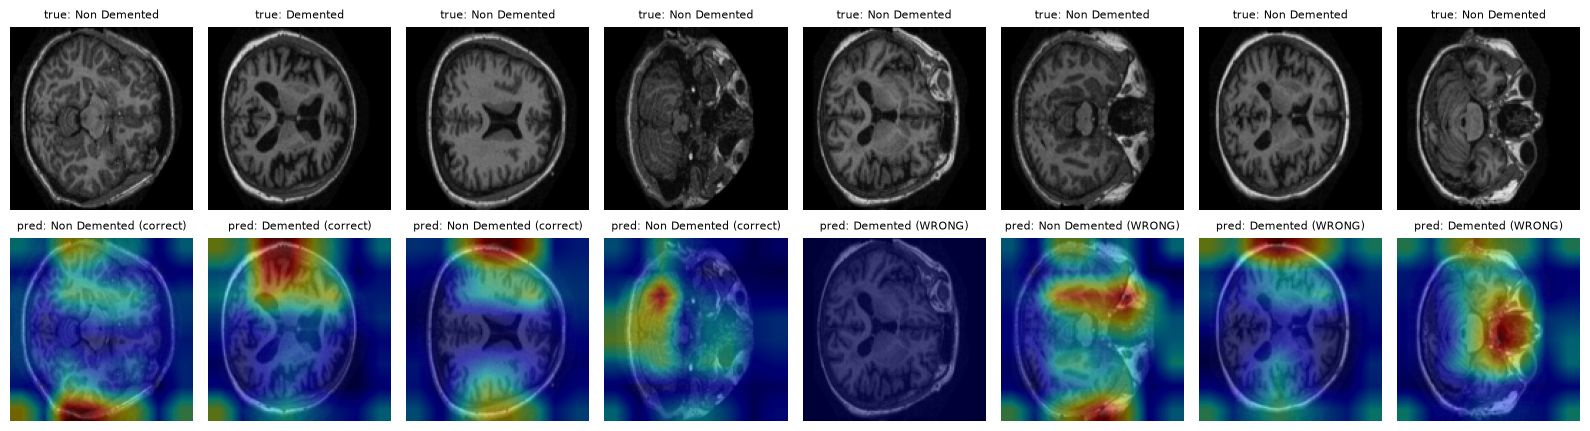

In [12]:
grad_model = tf.keras.Model(model.inputs, [model.get_layer("block5_conv4").output, model.layers[-1].input])
W, b = model.layers[-1].get_weights()

def gradcam_pp(img_uint8):
    x = preprocess_input(img_uint8[None].astype("float32"))
    with tf.GradientTape() as tape:
        conv, pen = grad_model(x)
        logits = tf.matmul(pen, W) + b
        c = int(tf.argmax(logits[0]))
        others = tf.concat([logits[:, :c], logits[:, c + 1:]], axis=1)
        score = logits[:, c] - tf.reduce_logsumexp(others, axis=1)   # log-odds of the predicted class
    g = tape.gradient(score, conv)[0]; A = conv[0]
    g2, g3 = g * g, g * g * g
    denom = 2 * g2 + g3 * tf.reduce_sum(A, axis=(0, 1))
    alpha = g2 / tf.where(denom != 0, denom, tf.ones_like(denom))
    alpha /= tf.reduce_sum(alpha, axis=(0, 1)) + 1e-8
    w = tf.reduce_sum(alpha * tf.nn.relu(g), axis=(0, 1))
    cam = tf.nn.relu(tf.reduce_sum(w * A, -1)); cam /= tf.reduce_max(cam) + 1e-8
    return tf.image.resize(cam[..., None], (IMG, IMG)).numpy().squeeze(), c

rng_g = np.random.default_rng(SEED)
right, wrong = np.where(pred == y_test)[0], np.where(pred != y_test)[0]
idx = np.concatenate([rng_g.choice(right, min(4, len(right)), replace=False),
                      rng_g.choice(wrong, min(4, len(wrong)), replace=False)])   # 4 correct + 4 mistakes
plt.figure(figsize=(16, 4.5))
for n, i in enumerate(idx):
    cam, c = gradcam_pp(X_test[i])
    plt.subplot(2, 8, n + 1); plt.imshow(X_test[i]); plt.axis("off"); plt.title(f"true: {CLASSES[y_test[i]]}", fontsize=8)
    tag = "correct" if pred[i] == y_test[i] else "WRONG"
    plt.subplot(2, 8, n + 9); plt.imshow(X_test[i]); plt.imshow(cam, cmap="jet", alpha=0.45); plt.axis("off"); plt.title(f"pred: {CLASSES[c]} ({tag})", fontsize=8)
plt.tight_layout(); plt.show()

## 8. Why the split matters — a controlled comparison

The same frozen VGG-19 features and the same dense head are trained twice with identical settings; only the split differs:
(a) a random split over slices (v1's protocol — slices of one brain end up in both train and test) vs
(b) the patient-level split used above. This is a single-seed reference experiment on frozen features (not the
fine-tuned model above); the gap shows how much a slice-level split inflates the score.

In [13]:
RUN_SLICE_SPLIT_REFERENCE = True
if RUN_SLICE_SPLIT_REFERENCE:
    feat_model = VGG19(weights="imagenet", include_top=False, input_shape=(IMG, IMG, 3))
    feats, y_all = [], []
    for k in ("train", "val", "test"):          # chunked: never materialise all images as float32
        Xk, yk = data[k]
        for i in range(0, len(yk), 1024):
            feats.append(feat_model.predict(preprocess_input(Xk[i:i + 1024].astype("float32")), verbose=0).astype(np.float16))
        y_all.append(yk)
    feats, y_all = np.concatenate(feats), np.concatenate(y_all)
    split_all = np.concatenate([[k] * len(data[k][1]) for k in ("train", "val", "test")])

    def head_accuracy(tr, te):
        tf.keras.utils.set_random_seed(SEED)
        inp = layers.Input(feats.shape[1:])
        h_ = layers.Dropout(0.5)(layers.Dense(128, activation="relu")(layers.Dropout(0.5)(layers.Dense(256, activation="relu")(layers.Flatten()(inp)))))
        head = tf.keras.Model(inp, layers.Dense(K, activation="softmax")(h_))
        head.compile("adam", "sparse_categorical_crossentropy", metrics=["accuracy"])
        head.fit(feats[tr], y_all[tr], validation_split=0.15, epochs=30, batch_size=128, verbose=0,
                 class_weight=class_weight, callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)])
        pr = head.predict(feats[te], verbose=0).argmax(1)
        recall = [(pr[y_all[te] == c] == c).mean() for c in range(K)]
        return float((pr == y_all[te]).mean()), float(np.mean(recall))

    perm = np.random.default_rng(SEED).permutation(len(y_all))
    n_te = int(0.15 * len(perm))
    random_split = head_accuracy(perm[n_te:], perm[:n_te])                                 # (a)
    patient_split = head_accuracy(np.where(split_all != "test")[0], np.where(split_all == "test")[0])   # (b)
    reference = {"random_slice_split": {"accuracy": random_split[0], "balanced_accuracy": random_split[1]},
                 "patient_split": {"accuracy": patient_split[0], "balanced_accuracy": patient_split[1]}}
    print(f"(a) random slice split : accuracy {random_split[0]:.3f} | balanced {random_split[1]:.3f}")
    print(f"(b) patient-level split: accuracy {patient_split[0]:.3f} | balanced {patient_split[1]:.3f}")

2026-09-29 15:13:24.831648: E external/local_xla/xla/service/gpu/autotuning/gemm_fusion_autotuner.cc:1138] Results do not match the reference. This is likely a bug/unexpected loss of precision.


(a) random slice split : accuracy 0.955 | balanced 0.965
(b) patient-level split: accuracy 0.748 | balanced 0.770


## 9. Save

In [14]:
model.save(os.path.join(OUT, "alzheimer_vgg19_v2.keras"))
config = {"seed": SEED, "img": IMG, "batch": BATCH, "warmup_epochs": WARMUP_EPOCHS, "finetune_epochs_max": FINETUNE_EPOCHS,
          "lr_head": 1e-3, "lr_finetune": 1e-5, "finetuned_layers": "block5", "augmentation": "vflip, rot 0.04, zoom 0.08, contrast 0.1",
          "preprocess": "vgg19", "classes": CLASSES}
metrics = {"task": TASK, "dataset": DATA, "config": config,
           "decision_threshold": SLICE_THRESHOLD, "patient_threshold": PATIENT_THRESHOLD,
           "counts": counts.to_dict(), "slice": slice_metrics, "patient": patient_metrics, "patient_ci95": patient_ci,
           "split_comparison": globals().get("reference")}
pd.DataFrame(pp, columns=[f"p_{c}" for c in CLASSES]).assign(
    subject=sorted(set(subjects_test)), true=[CLASSES[i] for i in py], predicted=[CLASSES[i] for i in patient_pred]
).to_csv(os.path.join(OUT, "test_patient_predictions.csv"), index=False)
json.dump(metrics, open(os.path.join(OUT, "metrics.json"), "w"), indent=2, default=float)
json.dump({k: sorted(v) for k, v in sets.items()}, open(os.path.join(OUT, "split_subjects.json"), "w"), indent=1)
print("Saved to", os.path.abspath(OUT), os.listdir(OUT))

Saved to /workspace/outputs ['split_subjects.json', 'metrics.json', 'test_patient_predictions.csv', 'alzheimer_vgg19_v2.keras']
